In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import os
os.makedirs("results/svm", exist_ok=True)


In [13]:
# ============================================================
# 1. LOAD CLEANED DATA
# ============================================================
FILE_PATH = "telco_churn_cleaned.csv"

df = pd.read_csv(FILE_PATH)

if "Churn" not in df.columns:
    raise ValueError("Column 'Churn' not found in dataset.")

X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget proportion:")
print(y.value_counts(normalize=True))

Dataset shape: (7032, 31)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Target proportion:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [14]:
# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5625, 30)
Test shape: (1407, 30)


In [15]:
# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================
def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    """Print evaluation metrics and return them as dict."""
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    print(f"\n{model_name}")
    print("-" * len(model_name))
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")
    
    return metrics


def find_best_threshold(y_true, y_prob, thresholds=np.arange(0.30, 0.70, 0.02)):
    """Find threshold that maximises F1 score."""
    best_f1 = 0
    best_threshold = 0.5
    
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thr
    
    return best_threshold, best_f1

In [16]:
# ============================================================
# 4. BASELINE SVM (scaling inside pipeline)
# ============================================================
print("=" * 50)
print("BASELINE SVM")
print("=" * 50)

baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, probability=True, random_state=50))
])

baseline_pipe.fit(X_train, y_train)

baseline_prob = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_pred = baseline_pipe.predict(X_test)

baseline_metrics = evaluate_model(y_test, baseline_pred, baseline_prob, "Baseline SVM")

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))

BASELINE SVM

Baseline SVM
------------
Accuracy: 0.7868
Precision: 0.6402
Recall: 0.4519
F1: 0.5298
ROC-AUC: 0.7735

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [17]:
# ============================================================
# 5. HYPERPARAMETER TUNING (GridSearchCV)
#    Scaling happens inside each CV fold via Pipeline
# ============================================================
print("=" * 50)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("=" * 50)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=50))
])

param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

HYPERPARAMETER TUNING (GridSearchCV)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV F1 score: 0.5962


In [18]:
# ============================================================
# 6. EVALUATE TUNED MODEL
# ============================================================
print("=" * 50)
print("TUNED SVM EVALUATION")
print("=" * 50)

best_svm = grid_search.best_estimator_

best_prob = best_svm.predict_proba(X_test)[:, 1]
best_pred = best_svm.predict(X_test)

tuned_metrics = evaluate_model(y_test, best_pred, best_prob, "Tuned SVM")

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

TUNED SVM EVALUATION

Tuned SVM
---------
Accuracy: 0.7946
Precision: 0.6451
Recall: 0.5053
F1: 0.5667
ROC-AUC: 0.8237

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [19]:
# ============================================================
# 7. THRESHOLD TUNING
# ============================================================
print("=" * 50)
print("THRESHOLD TUNING")
print("=" * 50)

best_threshold, best_f1_cv = find_best_threshold(y_test, best_prob)

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"F1 at optimal threshold: {best_f1_cv:.4f}")

# Apply optimal threshold
best_pred_thr = (best_prob >= best_threshold).astype(int)

threshold_metrics = evaluate_model(y_test, best_pred_thr, best_prob, "Tuned SVM + Threshold")

print("\nClassification Report:")
print(classification_report(y_test, best_pred_thr))

THRESHOLD TUNING
Optimal threshold: 0.30
F1 at optimal threshold: 0.6074

Tuned SVM + Threshold
---------------------
Accuracy: 0.7676
Precision: 0.5512
Recall: 0.6765
F1: 0.6074
ROC-AUC: 0.8237

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407



In [20]:
# ============================================================
# 8. RESULTS COMPARISON
# ============================================================
print("=" * 50)
print("RESULTS COMPARISON SVM")
print("=" * 50)

results_df = pd.DataFrame([baseline_metrics, tuned_metrics, threshold_metrics])
print(results_df.to_string(index=False))

RESULTS COMPARISON SVM
                Model  Accuracy  Precision   Recall       F1  ROC-AUC
         Baseline SVM  0.786780   0.640152 0.451872 0.529781 0.773521
            Tuned SVM  0.794598   0.645051 0.505348 0.566717 0.823690
Tuned SVM + Threshold  0.767591   0.551198 0.676471 0.607443 0.823690


Final chosen threshold: 0.30


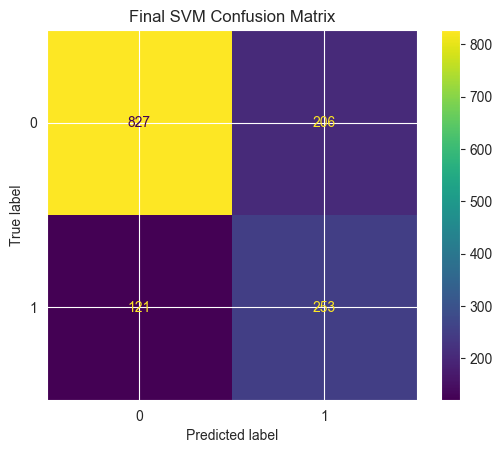

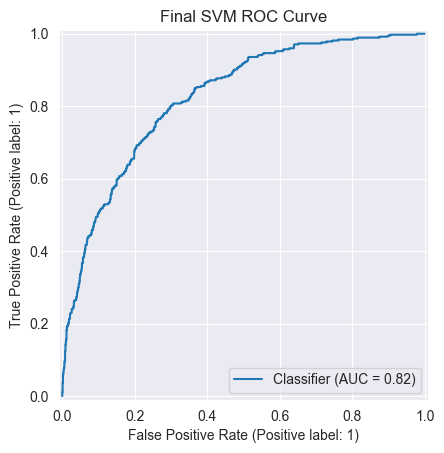

In [21]:
# ============================================================
# 9. VISUALISATIONS FOR FINAL MODEL
# ============================================================
final_model = best_svm
final_probs = best_prob
final_preds = best_pred_thr
final_threshold = best_threshold

print(f"Final chosen threshold: {final_threshold:.2f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, final_preds)
plt.title("Final SVM Confusion Matrix")
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, final_probs)
plt.title("Final SVM ROC Curve")
plt.show()

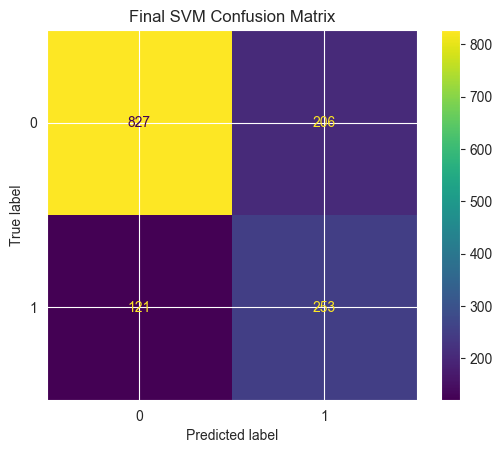

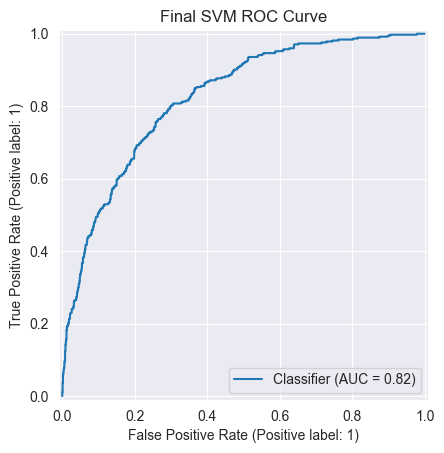


Files saved to results/svm/


In [22]:
# Save plots
ConfusionMatrixDisplay.from_predictions(y_test, final_preds)
plt.title("Final SVM Confusion Matrix")
plt.savefig("results/svm/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

RocCurveDisplay.from_predictions(y_test, final_probs)
plt.title("Final SVM ROC Curve")
plt.savefig("results/svm/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

# Save CSVs
results_df.to_csv("results/svm/svm_model_comparison.csv", index=False)

test_predictions = X_test.copy()
test_predictions["y_true"] = y_test.values
test_predictions["svm_prob"] = final_probs
test_predictions["svm_pred"] = final_preds
test_predictions.to_csv("results/svm/svm_test_predictions.csv", index=False)

print("\nFiles saved to results/svm/")